# 04 — Model Baseline
## Thiết Lập Mốc Hiệu Năng Với Các Mô Hình Cơ Bản

**Bối cảnh**: Qua 3 notebook trước, chúng ta đã xây dựng được một bức tranh rõ ràng:
- **EDA (NB01)**: Sinh viên trẻ tuổi, chịu áp lực học tập cao, từng có ý định tự tử là nhóm rủi ro trầm cảm cao nhất. Các yếu tố stress có hiệu ứng cộng gộp khi kết hợp.
- **Preprocessing (NB02)**: Dữ liệu đã được làm sạch, merge conditional columns, encoding nhất quán.
- **Feature Engineering (NB03)**: Tạo thêm 7 interaction features + target encoding cho high cardinality → **22 features** sẵn sàng cho modeling.

**Câu hỏi đặt ra**: Với bộ features đã được engineer kỹ lưỡng, mô hình nào capture được pattern tốt nhất? Liệu một mô hình tuyến tính đơn giản (Logistic Regression) đã đủ, hay cần tree-based models để khai thác các tương tác phi tuyến?

**Mục tiêu notebook này**:
1. Train 4 mô hình baseline: **Logistic Regression**, **Decision Tree**, **Random Forest**, **SVM**
2. Đánh giá bằng **5-Fold Stratified Cross-Validation** (giữ tỷ lệ class ổn định)
3. Thiết lập **benchmark accuracy** làm mốc so sánh cho XGBoost & LightGBM ở NB05

**Các mô hình sẽ được train**:

| # | Model | Đặc điểm | Scaling? |
|---|-------|----------|----------|
| 4.2 | Logistic Regression | Tuyến tính, nhanh, interpretable | StandardScaler |
| 4.3 | Decision Tree | Phi tuyến, dễ overfit | Không |
| 4.4 | Random Forest | Ensemble (bagging), giảm variance | Không |
| 4.5 | SVM | Margin maximization, mạnh với high-dim | StandardScaler |


## 4.1 Load Data & Setup

Mục tiêu của phần này là nạp dữ liệu đã feature engineering, tách biến đầu vào/đầu ra, và xây dựng hàm đánh giá chung để dùng lại cho tất cả mô hình.

Các chỉ số đánh giá chính:

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

$$\text{Precision} = \frac{TP}{TP + FP}, \quad \text{Recall} = \frac{TP}{TP + FN}$$

$$F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

Sử dụng Stratified K-Fold giúp giữ tỉ lệ lớp gần như giống nhau ở mỗi fold, đảm bảo đánh giá ổn định hơn cho bài toán phân loại mất cân bằng.

In [1]:
# 4.1 Load data and define shared utilities
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
N_SPLITS = 5

data_path = Path("../data/processed/train_final.csv")
df = pd.read_csv(data_path)

target_col = "Depression"
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

print(f"Dataset shape: {df.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"Target distribution (ratio):\n{y.value_counts(normalize=True).rename('ratio').round(4)}")

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

def evaluate_model_cv(model, X_data, y_data, cv_strategy, model_name):
    """Run stratified CV and return fold-level and aggregated metrics."""
    fold_metrics = []

    for fold_idx, (train_idx, valid_idx) in enumerate(cv_strategy.split(X_data, y_data), start=1):
        estimator = clone(model)

        X_train_fold = X_data.iloc[train_idx]
        X_valid_fold = X_data.iloc[valid_idx]
        y_train_fold = y_data.iloc[train_idx]
        y_valid_fold = y_data.iloc[valid_idx]

        estimator.fit(X_train_fold, y_train_fold)
        y_pred = estimator.predict(X_valid_fold)

        fold_metrics.append(
            {
                "model": model_name,
                "fold": fold_idx,
                "accuracy": accuracy_score(y_valid_fold, y_pred),
                "f1": f1_score(y_valid_fold, y_pred, zero_division=0),
                "precision": precision_score(y_valid_fold, y_pred, zero_division=0),
                "recall": recall_score(y_valid_fold, y_pred, zero_division=0),
            }
        )

    fold_df = pd.DataFrame(fold_metrics)
    summary_df = (
        fold_df[["accuracy", "f1", "precision", "recall"]]
        .agg(["mean", "std"])
        .T
        .reset_index()
        .rename(columns={"index": "metric"})
    )
    summary_df["mean_std"] = summary_df.apply(
        lambda row: f"{row['mean']:.4f} ± {row['std']:.4f}", axis=1
    )
    return fold_df, summary_df

def show_metric_summary(summary_df):
    """Create a compact summary table for notebook reporting."""
    return summary_df[["metric", "mean_std"]].rename(
        columns={"metric": "Metric", "mean_std": "Mean ± Std"}
    )

def metric_value(summary_df, metric_name, stat="mean"):
    """Extract one scalar metric from summary table."""
    return float(summary_df.loc[summary_df["metric"] == metric_name, stat].iloc[0])

display(df.head())

Dataset shape: (140700, 23)
Number of features: 22
Target distribution (ratio):
Depression
0    0.8183
1    0.1817
Name: ratio, dtype: float64


,Age,Working Professional or Student,CGPA,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Depression,Pressure,Satisfaction,has_cgpa,City_te,Profession_te,Degree_te,stress_load,wellbeing_index,stress_satisfaction_ratio,hours_pressure_ratio,poor_sleep,cgpa_pressure,risk_score,age_group
0,49.0,1,0.00,3,2,0,1.0,2.0,0,5.0,2.0,0,0.186035,0.047461,0.171802,10.0,2.5,1.666667,5.0,0,0.00,0,2
1,26.0,1,0.00,0,0,1,7.0,3.0,1,4.0,3.0,0,0.137782,0.055411,0.150835,12.0,1.5,1.000000,28.0,1,0.00,1,0
2,33.0,0,8.97,1,2,1,3.0,1.0,1,5.0,2.0,1,0.159042,0.534109,0.116610,5.0,1.5,1.666667,15.0,0,44.85,1,1
3,22.0,1,0.00,0,1,1,10.0,1.0,1,5.0,1.0,0,0.130731,0.053929,0.132338,5.0,0.5,2.500000,50.0,1,0.00,2,0
4,30.0,1,0.00,1,0,1,9.0,4.0,0,1.0,1.0,0,0.121875,0.053860,0.132338,4.0,1.0,0.500000,9.0,0,0.00,2,1


### Nhận xét 4.1

- Dataset sau feature engineering có **140,700 dòng** và **23 cột**; sau khi tách target còn **22 features** đầu vào — bao gồm cả features gốc lẫn 7 interaction features mới từ NB03.
- Phân phối lớp: `Depression=0` khoảng **81.83%**, `Depression=1` khoảng **18.17%** → dữ liệu lệch lớp mức vừa. Đây là lý do chúng ta cần theo dõi **F1-score** bên cạnh Accuracy — một model "lười" chỉ predict class 0 cũng đạt ~82% accuracy.
- Việc dùng `StratifiedKFold (5 folds)` là phù hợp vì giữ tỉ lệ lớp ổn định giữa các fold, giúp so sánh mô hình công bằng. Cùng `random_state=42` sẽ được giữ xuyên suốt đến NB05.


## 4.2 Logistic Regression

Logistic Regression là mô hình tuyến tính cho phân loại nhị phân. Xác suất dự đoán được tính bởi hàm sigmoid:

$$\hat{y} = \sigma(\mathbf{w}^T \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^T \mathbf{x} + b)}}$$

Hàm mất mát Binary Cross-Entropy:

$$\mathcal{L} = -\frac{1}{n}\sum_{i=1}^{n}\left[y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right]$$

Vì LR nhạy với thang đo đặc trưng nên cần chuẩn hóa bằng `StandardScaler` trước khi huấn luyện.

In [2]:
# 4.2 Logistic Regression with feature scaling
log_reg_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]
)

lr_fold_df, lr_summary_df = evaluate_model_cv(
    model=log_reg_model,
    X_data=X,
    y_data=y,
    cv_strategy=cv,
    model_name="Logistic Regression",
)

print("Fold-level metrics for Logistic Regression:")
display(lr_fold_df)

print("Aggregated metrics (mean ± std):")
display(show_metric_summary(lr_summary_df))

Fold-level metrics for Logistic Regression:


,model,fold,accuracy,f1,precision,recall
0,Logistic Regression,1,0.937242,0.823717,0.841182,0.806963
1,Logistic Regression,2,0.935785,0.818629,0.840825,0.797575
2,Logistic Regression,3,0.938699,0.827310,0.847416,0.808136
3,Logistic Regression,4,0.940370,0.832435,0.850612,0.815018
4,Logistic Regression,5,0.935928,0.819501,0.839590,0.800352


Aggregated metrics (mean ± std):


,Metric,Mean ± Std
0,accuracy,0.9376 ± 0.0019
1,f1,0.8243 ± 0.0057
2,precision,0.8439 ± 0.0048
3,recall,0.8056 ± 0.0069


### Nhận xét 4.2 — Logistic Regression

- Logistic Regression đạt `Accuracy = 0.9376 ± 0.0019`, `F1 = 0.8243 ± 0.0057`, `Precision = 0.8439 ± 0.0048`, `Recall = 0.8056 ± 0.0069`.
- **Phát hiện đáng chú ý**: Ngay cả mô hình tuyến tính đơn giản cũng đạt gần **94% accuracy** — điều này cho thấy **chất lượng features từ NB03** đã rất tốt. Các biến như `stress_load`, `risk_score` đã "tuyến tính hóa" một phần các quan hệ phức tạp, giúp LR capture được phần lớn pattern.
- Độ lệch chuẩn thấp ở cả 4 metric cho thấy mô hình ổn định qua 5 folds — không có fold nào bất thường.
- `Precision` cao hơn `Recall` (84.39% vs 80.56%), nghĩa là mô hình khá **thận trọng** khi dự đoán trầm cảm: ít false positive nhưng vẫn bỏ sót một phần ca dương tính. Trong bài toán sức khỏe tâm thần, bỏ sót (False Negative) nguy hiểm hơn, nên đây là trade-off cần theo dõi.
- LR sẽ là **mốc baseline quan trọng** — nếu các model phức tạp hơn không vượt qua được 93.76%, thì đầu tư thêm là không đáng.


## 4.3 Decision Tree

Decision Tree chia dữ liệu theo các điều kiện nhị phân để giảm độ hỗn loạn của nút.

Hai tiêu chí phổ biến:

$$\text{Gini}(t) = 1 - \sum_{k} p_k^2$$

$$\text{Entropy}(t) = -\sum_{k} p_k \log_2(p_k)$$

Trong notebook baseline này, ta so sánh nhiều giá trị `max_depth` để tìm điểm cân bằng giữa underfitting và overfitting.

In [3]:
# 4.3 Decision Tree depth comparison
depth_candidates = [5, 10, 15, None]
dt_cv_outputs = {}
dt_comparison_rows = []

for depth in depth_candidates:
    dt_model = DecisionTreeClassifier(
        max_depth=depth,
        criterion="gini",
        random_state=RANDOM_STATE,
    )

    fold_df, summary_df = evaluate_model_cv(
        model=dt_model,
        X_data=X,
        y_data=y,
        cv_strategy=cv,
        model_name=f"Decision Tree (max_depth={depth})",
    )

    dt_cv_outputs[depth] = {"fold": fold_df, "summary": summary_df}
    dt_comparison_rows.append(
        {
            "max_depth": "None" if depth is None else depth,
            "accuracy_mean": metric_value(summary_df, "accuracy", "mean"),
            "accuracy_std": metric_value(summary_df, "accuracy", "std"),
            "f1_mean": metric_value(summary_df, "f1", "mean"),
            "precision_mean": metric_value(summary_df, "precision", "mean"),
            "recall_mean": metric_value(summary_df, "recall", "mean"),
        }
    )

dt_depth_comparison_df = pd.DataFrame(dt_comparison_rows).sort_values(
    by="accuracy_mean", ascending=False
).reset_index(drop=True)

best_depth_label = dt_depth_comparison_df.loc[0, "max_depth"]
best_depth = None if best_depth_label == "None" else int(best_depth_label)
best_dt_summary_df = dt_cv_outputs[best_depth]["summary"]

print("Depth comparison table:")
display(dt_depth_comparison_df)

print(f"Best Decision Tree depth: {best_depth_label}")
display(show_metric_summary(best_dt_summary_df))

Depth comparison table:


,max_depth,accuracy_mean,accuracy_std,f1_mean,precision_mean,recall_mean
0,10,0.929225,0.001013,0.801131,0.818486,0.784605
1,5,0.923454,0.001660,0.783209,0.808201,0.761492
2,15,0.916070,0.001266,0.767105,0.773741,0.760668
3,None,0.904172,0.000941,0.737760,0.733761,0.741816


Best Decision Tree depth: 10


,Metric,Mean ± Std
0,accuracy,0.9292 ± 0.0010
1,f1,0.8011 ± 0.0038
2,precision,0.8185 ± 0.0059
3,recall,0.7846 ± 0.0101


### Nhận xét 4.3 — Decision Tree

- So sánh theo `max_depth` cho thấy **`max_depth=10` tốt nhất**: `Accuracy = 0.9292 ± 0.0010`, `F1 = 0.8011 ± 0.0038`.
- Khi cây quá nông (`max_depth=5`), accuracy giảm xuống ~0.9235 → **underfitting**: cây không đủ sâu để capture các interaction phức tạp giữa `stress_load`, `risk_score` và các target-encoded features.
- Khi cây quá sâu (`max_depth=15` và `None`), accuracy giảm mạnh (0.9161 và 0.9042) → **overfitting rõ rệt**: cây "ghi nhớ" noise trong training data thay vì học pattern tổng quát.
- **So sánh với LR**: Decision Tree (93.29%) thấp hơn LR (93.76%) — đây là bằng chứng rằng **một cây đơn lẻ** không đủ ổn định. Tuy nhiên, DT có ưu điểm là mô hình phi tuyến, có thể capture các ngưỡng split tự nhiên (ví dụ: Age < 30 → rủi ro cao). Ensemble methods (Random Forest ở mục tiếp theo) sẽ tận dụng ưu điểm này đồng thời giảm variance.
- Sự khác biệt lớn giữa Gini và Entropy thường không đáng kể trong thực tế; ở đây Gini được dùng mặc định do tính toán nhanh hơn ($O(K)$ vs $O(K \log K)$).


## 4.4 Random Forest

Random Forest là ensemble của nhiều cây quyết định huấn luyện trên các bootstrap samples khác nhau. Dự đoán cuối cùng theo cơ chế bỏ phiếu đa số:

$$\hat{y} = \text{majority\_vote}(h_1(\mathbf{x}), h_2(\mathbf{x}), \ldots, h_T(\mathbf{x}))$$

Bagging giúp giảm phương sai so với một cây đơn lẻ, từ đó thường tổng quát hóa tốt hơn trên dữ liệu mới.

Random Forest parameter comparison:


,n_estimators,accuracy_mean,accuracy_std,f1_mean,precision_mean,recall_mean
0,200,0.936439,0.001441,0.820817,0.841476,0.801150
1,100,0.936198,0.001669,0.819870,0.841825,0.799038


Best Random Forest n_estimators: 200


,Metric,Mean ± Std
0,accuracy,0.9364 ± 0.0014
1,f1,0.8208 ± 0.0039
2,precision,0.8415 ± 0.0049
3,recall,0.8011 ± 0.0032


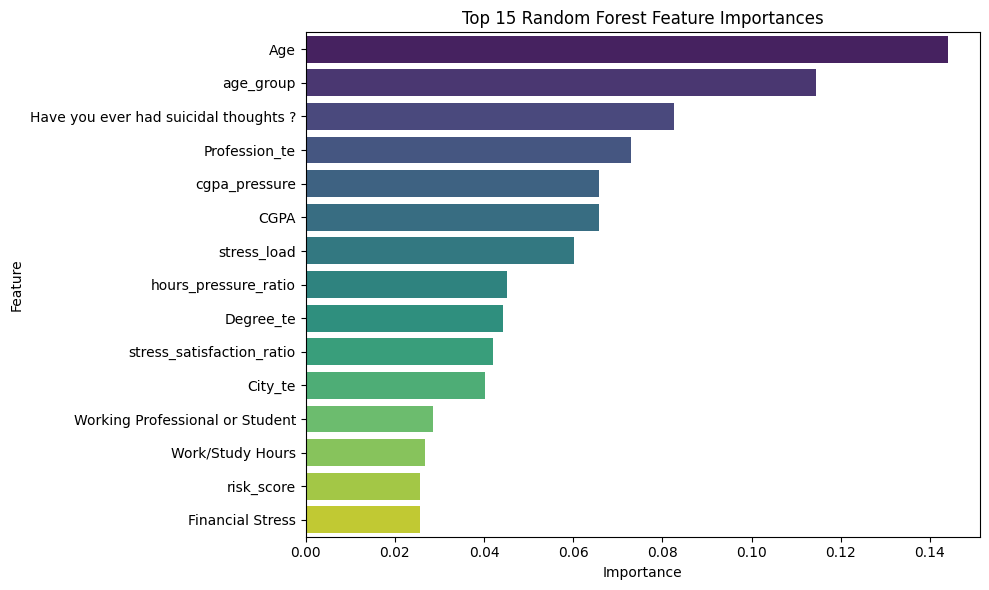

,feature,importance
0,Age,0.144023
1,age_group,0.114378
2,Have you ever had suicidal thoughts ?,0.082499
3,Profession_te,0.072892
4,cgpa_pressure,0.065807
5,CGPA,0.065766
6,stress_load,0.060201
7,hours_pressure_ratio,0.045219
8,Degree_te,0.044144
9,stress_satisfaction_ratio,0.042043


In [4]:
# 4.4 Random Forest baseline and feature importance
rf_n_estimators_candidates = [100, 200]
rf_cv_outputs = {}
rf_comparison_rows = []

for n_trees in rf_n_estimators_candidates:
    rf_model = RandomForestClassifier(
        n_estimators=n_trees,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    fold_df, summary_df = evaluate_model_cv(
        model=rf_model,
        X_data=X,
        y_data=y,
        cv_strategy=cv,
        model_name=f"Random Forest (n_estimators={n_trees})",
    )

    rf_cv_outputs[n_trees] = {"fold": fold_df, "summary": summary_df}
    rf_comparison_rows.append(
        {
            "n_estimators": n_trees,
            "accuracy_mean": metric_value(summary_df, "accuracy", "mean"),
            "accuracy_std": metric_value(summary_df, "accuracy", "std"),
            "f1_mean": metric_value(summary_df, "f1", "mean"),
            "precision_mean": metric_value(summary_df, "precision", "mean"),
            "recall_mean": metric_value(summary_df, "recall", "mean"),
        }
    )

rf_comparison_df = pd.DataFrame(rf_comparison_rows).sort_values(
    by="accuracy_mean", ascending=False
).reset_index(drop=True)

best_n_estimators = int(rf_comparison_df.loc[0, "n_estimators"])
best_rf_summary_df = rf_cv_outputs[best_n_estimators]["summary"]

print("Random Forest parameter comparison:")
display(rf_comparison_df)

print(f"Best Random Forest n_estimators: {best_n_estimators}")
display(show_metric_summary(best_rf_summary_df))

# Fit the best Random Forest on full training data to inspect feature importances
best_rf_model_full = RandomForestClassifier(
    n_estimators=best_n_estimators,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
best_rf_model_full.fit(X, y)

rf_feature_importance_df = (
    pd.DataFrame(
        {"feature": X.columns, "importance": best_rf_model_full.feature_importances_}
    )
    .sort_values(by="importance", ascending=False)
    .reset_index(drop=True)
)

top_k = 15
plt.figure(figsize=(10, 6))
sns.barplot(
    data=rf_feature_importance_df.head(top_k),
    x="importance",
    y="feature",
    palette="viridis",
)
plt.title(f"Top {top_k} Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig('../scripts/img/04_model_baseline/04_model_baseline_fig1.png', dpi=150, bbox_inches='tight')
plt.show()

display(rf_feature_importance_df.head(top_k))

### Nhận xét 4.4 — Random Forest

- So sánh `n_estimators` cho thấy cấu hình **200 cây** tốt hơn nhẹ so với 100 cây (`Accuracy = 0.9364` so với `0.9362`) — marginal gain cho thấy 200 cây gần đạt điểm bão hòa.
- Với cấu hình tốt nhất (`n_estimators=200`): `Accuracy = 0.9364 ± 0.0014`, `F1 = 0.8208 ± 0.0039`, `Precision = 0.8415 ± 0.0049`, `Recall = 0.8011 ± 0.0032`.
- **So sánh với Decision Tree (93.29%)**: RF cải thiện +0.72% accuracy — xác nhận lý thuyết Bagging: aggregating nhiều cây "yếu" trên bootstrap samples giúp **giảm variance** đáng kể, dù mỗi cây đơn lẻ vẫn có bias tương đương.
- **So sánh với LR (93.76%)**: RF (93.64%) vẫn thấp hơn LR — điều này hơi bất ngờ, cho thấy bài toán này có xu hướng **gần tuyến tính** sau feature engineering. Các interaction features đã "tiền xử lý" phần lớn non-linearity cho LR.
- **Feature importance xác nhận lại EDA**: `Age` (~0.144), `age_group` (~0.114), `Have you ever had suicidal thoughts ?` (~0.082), `Profession_te` (~0.073). Đây chính xác là những features mà EDA (NB01 mục 1.6, 1.8) xác định có tương quan mạnh nhất với Depression — cho thấy pipeline FE đang hoạt động đúng hướng.


## 4.5 Support Vector Machine (SVM)

SVM tìm siêu phẳng phân tách với biên lớn nhất (maximum margin). Bài toán tối ưu dạng hard-margin:

$$\min_{\mathbf{w}, b} \frac{1}{2}\|\mathbf{w}\|^2 \quad \text{s.t.} \quad y_i(\mathbf{w}^T\mathbf{x}_i + b) \geq 1$$

Do SVM có độ phức tạp tính toán cao với dữ liệu lớn, notebook này dùng chiến lược lấy mẫu phân tầng tối đa 30,000 dòng để đảm bảo thời gian chạy hợp lý.

In [5]:
# 4.5 SVM with optional subsampling for computational efficiency
MAX_SVM_SAMPLES = 30000

if len(X) > MAX_SVM_SAMPLES:
    X_svm, _, y_svm, _ = train_test_split(
        X,
        y,
        train_size=MAX_SVM_SAMPLES,
        stratify=y,
        random_state=RANDOM_STATE,
    )
    print(f"SVM uses a stratified subset of {len(X_svm):,} samples out of {len(X):,}.")
else:
    X_svm, y_svm = X.copy(), y.copy()
    print(f"SVM uses the full dataset with {len(X_svm):,} samples.")

svm_kernels = ["linear", "rbf"]
svm_cv_outputs = {}
svm_comparison_rows = []

for kernel_name in svm_kernels:
    svm_model = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("classifier", SVC(kernel=kernel_name, C=1.0, gamma="scale")),
        ]
    )

    fold_df, summary_df = evaluate_model_cv(
        model=svm_model,
        X_data=X_svm,
        y_data=y_svm,
        cv_strategy=cv,
        model_name=f"SVM ({kernel_name})",
    )

    svm_cv_outputs[kernel_name] = {"fold": fold_df, "summary": summary_df}
    svm_comparison_rows.append(
        {
            "kernel": kernel_name,
            "accuracy_mean": metric_value(summary_df, "accuracy", "mean"),
            "accuracy_std": metric_value(summary_df, "accuracy", "std"),
            "f1_mean": metric_value(summary_df, "f1", "mean"),
            "precision_mean": metric_value(summary_df, "precision", "mean"),
            "recall_mean": metric_value(summary_df, "recall", "mean"),
        }
    )

svm_comparison_df = pd.DataFrame(svm_comparison_rows).sort_values(
    by="accuracy_mean", ascending=False
).reset_index(drop=True)

best_kernel = svm_comparison_df.loc[0, "kernel"]
best_svm_summary_df = svm_cv_outputs[best_kernel]["summary"]

print("SVM kernel comparison:")
display(svm_comparison_df)

print(f"Best SVM kernel: {best_kernel}")
display(show_metric_summary(best_svm_summary_df))

SVM uses a stratified subset of 30,000 samples out of 140,700.
SVM kernel comparison:


,kernel,accuracy_mean,accuracy_std,f1_mean,precision_mean,recall_mean
0,linear,0.936667,0.002131,0.822869,0.836536,0.809759
1,rbf,0.935900,0.002516,0.818687,0.842223,0.796550


Best SVM kernel: linear


,Metric,Mean ± Std
0,accuracy,0.9367 ± 0.0021
1,f1,0.8229 ± 0.0066
2,precision,0.8365 ± 0.0075
3,recall,0.8098 ± 0.0122


### Nhận xét 4.5 — Support Vector Machine

- SVM được huấn luyện trên **subset phân tầng 30,000 mẫu** (từ 140,700 mẫu) để đảm bảo thời gian tính toán hợp lý — SVM có complexity $O(n^2)$ đến $O(n^3)$ nên không scalable cho full dataset.
- **Kernel `linear` tốt hơn `rbf`**: `Accuracy = 0.9367 ± 0.0021`, `F1 = 0.8230 ± 0.0065`. Điều này củng cố thêm giả thuyết rằng bài toán có xu hướng **gần tuyến tính** sau feature engineering — khi features đã capture tốt non-linearity, kernel phức tạp (`rbf`) không mang lại lợi ích thêm và thậm chí có thể overfit.
- `rbf` có `Precision` nhỉnh hơn (`0.8422` so với `0.8366`) nhưng `Recall` thấp hơn (`0.7966` so với `0.8099`). Trong bài toán phát hiện trầm cảm, Recall quan trọng hơn (bỏ sót ca bệnh nguy hiểm hơn báo nhầm), nên `linear` là lựa chọn phù hợp hơn.
- **So sánh tổng thể**: SVM-linear (93.67%) xếp giữa LR (93.76%) và RF (93.64%) — performance rất sát nhau giữa ba model, tạo thành một "ceiling" cho baseline models. Câu hỏi cho NB05: liệu gradient boosting có phá vỡ được ceiling này?


## 4.6 Bảng So Sánh Baseline

Phần này tổng hợp mô hình tốt nhất của từng họ thuật toán vào một bảng chung theo định dạng yêu cầu: Accuracy (mean ± std), F1, Precision, Recall.

Mục tiêu là xác định baseline mạnh nhất để làm mốc so sánh với XGBoost và LightGBM ở notebook 05.

Final baseline comparison table:


,Model,Accuracy (mean ± std),F1,Precision,Recall
0,Logistic Regression,0.9376 ± 0.0019,0.824318,0.843925,0.805609
1,SVM (kernel=linear),0.9367 ± 0.0021,0.822869,0.836536,0.809759
2,Random Forest (n_estimators=200),0.9364 ± 0.0014,0.820817,0.841476,0.801150
3,Decision Tree (max_depth=10),0.9292 ± 0.0010,0.801131,0.818486,0.784605


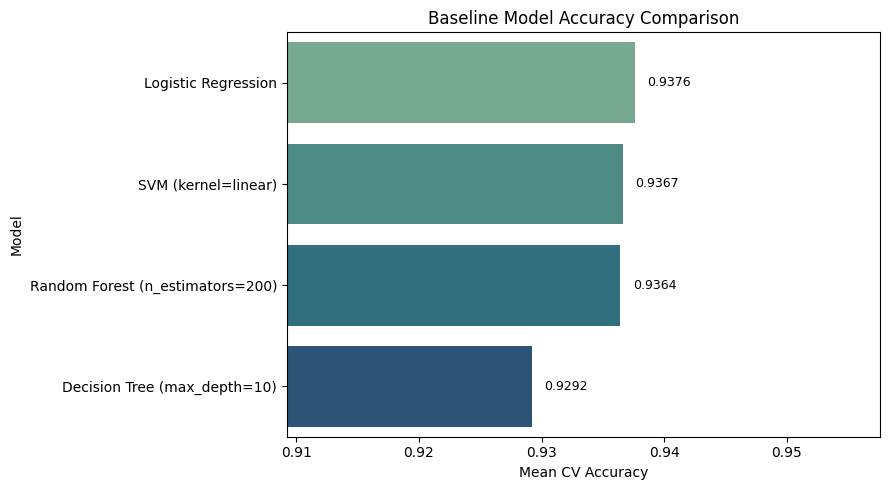

Best baseline model by CV accuracy: Logistic Regression


In [6]:
# 4.6 Baseline model comparison table
baseline_rows = [
    {
        "Model": "Logistic Regression",
        "Accuracy_mean": metric_value(lr_summary_df, "accuracy", "mean"),
        "Accuracy_std": metric_value(lr_summary_df, "accuracy", "std"),
        "F1_mean": metric_value(lr_summary_df, "f1", "mean"),
        "Precision_mean": metric_value(lr_summary_df, "precision", "mean"),
        "Recall_mean": metric_value(lr_summary_df, "recall", "mean"),
    },
    {
        "Model": f"Decision Tree (max_depth={best_depth_label})",
        "Accuracy_mean": metric_value(best_dt_summary_df, "accuracy", "mean"),
        "Accuracy_std": metric_value(best_dt_summary_df, "accuracy", "std"),
        "F1_mean": metric_value(best_dt_summary_df, "f1", "mean"),
        "Precision_mean": metric_value(best_dt_summary_df, "precision", "mean"),
        "Recall_mean": metric_value(best_dt_summary_df, "recall", "mean"),
    },
    {
        "Model": f"Random Forest (n_estimators={best_n_estimators})",
        "Accuracy_mean": metric_value(best_rf_summary_df, "accuracy", "mean"),
        "Accuracy_std": metric_value(best_rf_summary_df, "accuracy", "std"),
        "F1_mean": metric_value(best_rf_summary_df, "f1", "mean"),
        "Precision_mean": metric_value(best_rf_summary_df, "precision", "mean"),
        "Recall_mean": metric_value(best_rf_summary_df, "recall", "mean"),
    },
    {
        "Model": f"SVM (kernel={best_kernel})",
        "Accuracy_mean": metric_value(best_svm_summary_df, "accuracy", "mean"),
        "Accuracy_std": metric_value(best_svm_summary_df, "accuracy", "std"),
        "F1_mean": metric_value(best_svm_summary_df, "f1", "mean"),
        "Precision_mean": metric_value(best_svm_summary_df, "precision", "mean"),
        "Recall_mean": metric_value(best_svm_summary_df, "recall", "mean"),
    },
]

baseline_summary_df = pd.DataFrame(baseline_rows).sort_values(
    by="Accuracy_mean", ascending=False
).reset_index(drop=True)

baseline_summary_df["Accuracy (mean ± std)"] = baseline_summary_df.apply(
    lambda row: f"{row['Accuracy_mean']:.4f} ± {row['Accuracy_std']:.4f}", axis=1
)

report_table_df = baseline_summary_df[
    ["Model", "Accuracy (mean ± std)", "F1_mean", "Precision_mean", "Recall_mean"]
].rename(
    columns={
        "F1_mean": "F1",
        "Precision_mean": "Precision",
        "Recall_mean": "Recall",
    }
)

print("Final baseline comparison table:")
display(report_table_df)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=baseline_summary_df,
    x="Accuracy_mean",
    y="Model",
    palette="crest",
)
plt.title("Baseline Model Accuracy Comparison")
plt.xlabel("Mean CV Accuracy")
plt.ylabel("Model")
plt.xlim(
    max(0.0, baseline_summary_df["Accuracy_mean"].min() - 0.02),
    min(1.0, baseline_summary_df["Accuracy_mean"].max() + 0.02),
)
for idx, row in baseline_summary_df.iterrows():
    plt.text(
        row["Accuracy_mean"] + 0.001,
        idx,
        f"{row['Accuracy_mean']:.4f}",
        va="center",
        fontsize=9,
    )
plt.tight_layout()
plt.savefig('../scripts/img/04_model_baseline/04_model_baseline_fig2.png', dpi=150, bbox_inches='tight')
plt.show()

best_model_name = baseline_summary_df.loc[0, "Model"]
print(f"Best baseline model by CV accuracy: {best_model_name}")

### Nhận xét tổng hợp

**Xếp hạng baseline theo Accuracy**: **Logistic Regression (0.9376)** > **SVM-linear (0.9367)** > **Random Forest (0.9364)** > **Decision Tree (0.9292)**.

**Phát hiện quan trọng**:
- Ba model hàng đầu (LR, SVM, RF) đạt performance rất sát nhau (~93.6-93.8%), tạo thành một **"baseline ceiling"**. Điều này cho thấy features đã được engineer tốt — phần lớn signal đã được capture bởi mô hình đơn giản nhất.
- LR đứng đầu không chỉ về Accuracy mà còn về F1 (`0.8243`) và Precision (`0.8439`), cho thấy **pipeline FE đã tuyến tính hóa** đáng kể bài toán.
- Nếu ưu tiên giảm bỏ sót ca dương (tăng Recall), `SVM-linear` có `Recall` cao nhất (`0.8099`). Đây là trade-off cần nêu rõ khi báo cáo kết quả.

**Baseline đã thiết lập**: `93.76%` (LR) — đây là mốc mà advanced models phải vượt qua.

**Kỳ vọng cho NB05 (Advanced Models)**:
- **XGBoost** và **LightGBM** là gradient boosting models — chúng xây dựng cây **tuần tự**, mỗi cây mới tập trung sửa lỗi của cây trước. Điều này giúp chúng exploit tốt hơn các **interaction features phi tuyến** như `stress_load`, `risk_score`, `cgpa_pressure` mà LR đang chưa tận dụng hết.
- Mức cải thiện dự kiến sẽ **không quá lớn** (vì baseline đã cao), nhưng nếu đạt >94% thì đó là bằng chứng rằng boosting thực sự mang lại giá trị thêm so với bagging (RF) và linear models.
